In [305]:
import pandas as pd

df_train = pd.read_csv('data/Train.csv')
df_test = pd.read_csv('data/Test.csv')
df_train.head()

,Unnamed: 0,acc_max,gyro_max,acc_kurtosis,gyro_kurtosis,label,lin_max,acc_skewness,gyro_skewness,post_gyro_max,post_lin_max,fall
0,661,26.039919,7.309797,20.378162,2.782476,SDL,11.131080,3.891361,1.592927,7.086618,10.790400,1
1,122,25.864500,6.511954,14.187190,5.324864,FOL,7.945561,3.022175,2.376939,6.325522,7.719352,1
2,113,27.524501,12.944099,31.855926,22.891186,FOL,14.454818,4.849024,4.283890,12.888111,14.368784,1
3,14,30.647705,11.694868,23.608764,9.287735,FOL,15.228303,3.921537,2.794609,11.549971,14.944151,1
4,529,26.373917,11.168424,14.318453,15.983202,FKL,10.007396,3.087975,3.363557,11.057636,9.753058,1


In [306]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1428 entries, 0 to 1427
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1428 non-null   int64  
 1   acc_max        1428 non-null   float64
 2   gyro_max       1428 non-null   float64
 3   acc_kurtosis   1428 non-null   float64
 4   gyro_kurtosis  1428 non-null   float64
 5   label          1428 non-null   object 
 6   lin_max        1428 non-null   float64
 7   acc_skewness   1428 non-null   float64
 8   gyro_skewness  1428 non-null   float64
 9   post_gyro_max  1428 non-null   float64
 10  post_lin_max   1428 non-null   float64
 11  fall           1428 non-null   int64  
dtypes: float64(9), int64(2), object(1)
memory usage: 134.0+ KB


In [307]:
df_train_clean = df_train.drop(columns=['Unnamed: 0',
                                        'label',
                                        'fall'])

df_test_clean = df_test.drop(columns=['Unnamed: 0',
                                        'label',
                                        'fall'])

In [308]:
df_test_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   acc_max        356 non-null    float64
 1   gyro_max       356 non-null    float64
 2   acc_kurtosis   356 non-null    float64
 3   gyro_kurtosis  356 non-null    float64
 4   lin_max        356 non-null    float64
 5   acc_skewness   356 non-null    float64
 6   gyro_skewness  356 non-null    float64
 7   post_gyro_max  356 non-null    float64
 8   post_lin_max   356 non-null    float64
dtypes: float64(9)
memory usage: 25.2 KB


In [309]:
df_train_clean.describe()

,acc_max,gyro_max,acc_kurtosis,gyro_kurtosis,lin_max,acc_skewness,gyro_skewness,post_gyro_max,post_lin_max
count,1428.000000,1428.000000,1428.000000,1428.000000,1428.000000,1428.000000,1428.000000,1428.000000,1428.000000
mean,21.753410,5.051467,9.964558,3.906186,7.934861,1.711623,1.626049,3.232624,5.190129
std,5.479771,2.965499,11.987739,5.495657,4.249702,1.530360,0.999605,3.432610,4.991879
min,9.787964,0.026257,-1.743347,-1.532044,0.043625,-14.066208,-0.460160,-4.939745,-5.382828
25%,18.822419,3.159428,0.468756,0.182250,4.818588,0.452138,0.811533,0.347634,0.893603
50%,22.866648,4.558629,8.575117,2.028413,8.233184,1.513125,1.529417,2.456817,3.696021
75%,25.863247,6.484719,15.475659,5.456435,11.064898,2.865099,2.291334,5.224912,9.486155
max,32.885551,17.288546,231.134385,32.301675,25.382307,6.782592,5.174101,16.204944,23.972115


In [310]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

df_train_scaled = pd.DataFrame(ss.fit_transform(df_train_clean), 
                               columns=df_train_clean.columns)

df_test_scaled = pd.DataFrame(ss.transform(df_test_clean), 
                              columns=df_test_clean.columns)

In [311]:
%%timeit
# logistic regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(df_train_scaled, df_train.fall)
lr.score(df_test_scaled, df_test['fall'])

17.9 ms ± 3.04 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [312]:
df_test_scaled.describe().T['std']

acc_max          1.001868
gyro_max         0.964005
acc_kurtosis     0.936331
gyro_kurtosis    0.995933
lin_max          1.011554
acc_skewness     0.997672
gyro_skewness    0.998695
post_gyro_max    0.996005
post_lin_max     1.013458
Name: std, dtype: float64

In [313]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_train_reducted = pca.fit_transform(df_train_scaled)
df_test_reducted = pca.transform(df_test_scaled)


In [314]:
# logistic regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(df_train_reducted, df_train.fall)
lr.score(df_test_reducted, df_test['fall'])

0.952247191011236

In [315]:
df_train_reducted.shape

(1428, 2)

[]

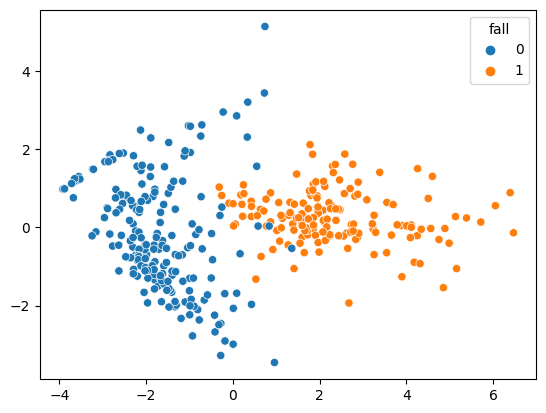

In [316]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=df_test_reducted[:,0], 
                y= df_test_reducted[:,1],
                hue=df_test['fall'])
plt.plot()

[]

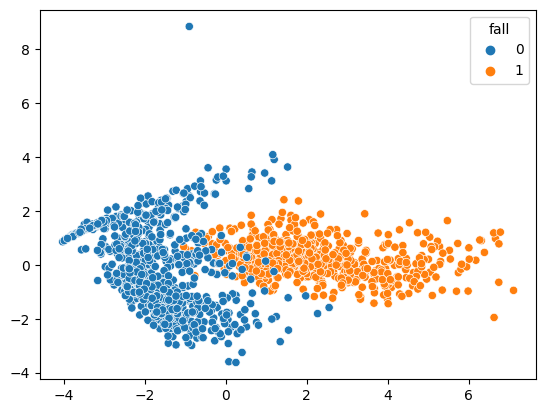

In [317]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=df_train_reducted[:,0], 
                y= df_train_reducted[:,1],
                hue=df_train['fall'])
plt.plot()

In [318]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=2)
df_train_reducted = lda.fit_transform(df_train_scaled, df_train['label'])
df_test_reducted = lda.transform(df_test_scaled)

In [319]:
# logistic regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(df_train_reducted, df_train.fall)
lr.score(df_test_reducted, df_test['fall'])

0.9747191011235955

In [320]:
df_test_reducted.shape

(356, 2)

[]

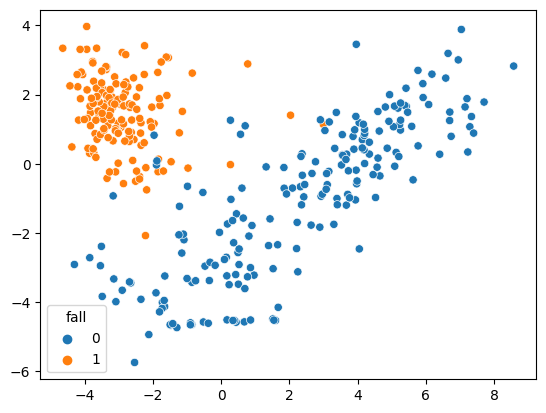

In [321]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=df_test_reducted[:,0], 
                y= df_test_reducted[:,1],
                hue=df_test['fall'])
plt.plot()

[]

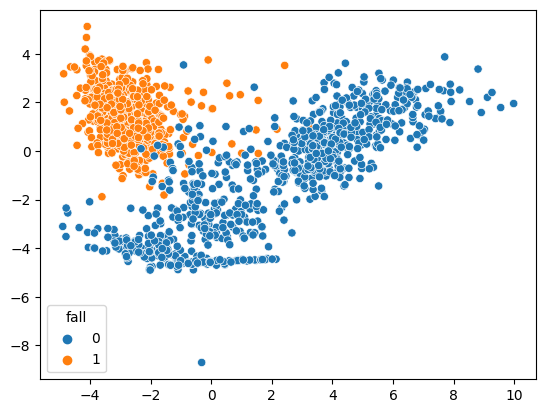

In [322]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=df_train_reducted[:,0], 
                y= df_train_reducted[:,1],
                hue=df_train['fall'])
plt.plot()

In [323]:
from sklearn.manifold import TSNE

tsne = TSNE(2)

df_train_reducted = tsne.fit_transform(df_train_scaled)
df_test_reducted = tsne.fit_transform(df_test_scaled)


In [324]:
%%timeit
# logistic regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(df_train_reducted, df_train.fall)
lr.score(df_test_reducted, df_test['fall'])

4.68 ms ± 501 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [325]:
df_train_reducted.shape

(1428, 2)

[]

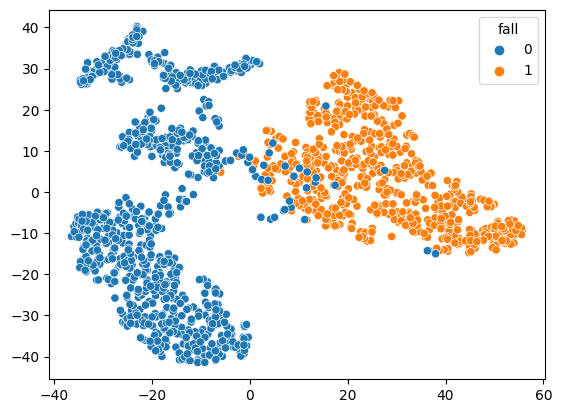

In [326]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=df_train_reducted[:,0], 
                y= df_train_reducted[:,1],
                hue=df_train['fall'])
plt.plot()

In [327]:
df_train.label.value_counts()

label
FKL    158
SDL    154
BSC    154
FOL    148
WAL     94
SCH     93
CSI     91
STN     91
STD     90
JOG     90
STU     89
JUM     89
CSO     87
Name: count, dtype: int64

# TASK

1. lakukan hal serupa untuk column 'label'
2. hitung (acc) score [min: 0.7123] dan waktunya (avg) [min: 6.85 ms] dengan menggunakan timeit

In [328]:
from sklearn.decomposition import PCA

pca = PCA(n_components=8)
df_train_reducted = pca.fit_transform(df_train_scaled)
df_test_reducted = pca.transform(df_test_scaled)

In [329]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(df_train_scaled, df_train['label'])

LogisticRegression(max_iter=1000)

In [330]:
%%timeit
lr.score(df_test_scaled, df_test['label'])

1.56 ms ± 126 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [331]:
%%timeit
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, solver='liblinear', tol=0.1)
lr.fit(df_train_reducted, df_train['label'])
lr.score(df_test_reducted, df_test['label'])

13.8 ms ± 547 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [332]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(df_train_reducted, df_train['label'])
print('Accuracy PCA:', lr.score(df_test_reducted, df_test['label']))

Accuracy PCA: 0.7191011235955056


In [333]:
df_train_reducted.shape

(1428, 8)

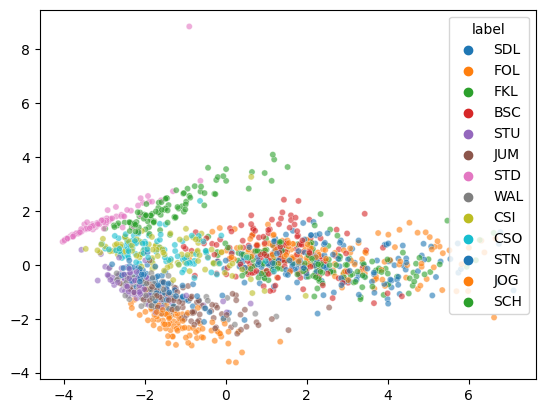

In [334]:
palette = sns.color_palette("tab10", df_train['label'].nunique())

sns.scatterplot(x=df_train_reducted[:,0],
                y=df_train_reducted[:,1],
                hue=df_train['label'],
                palette=palette,   
                alpha=0.6, s=20)
plt.show()

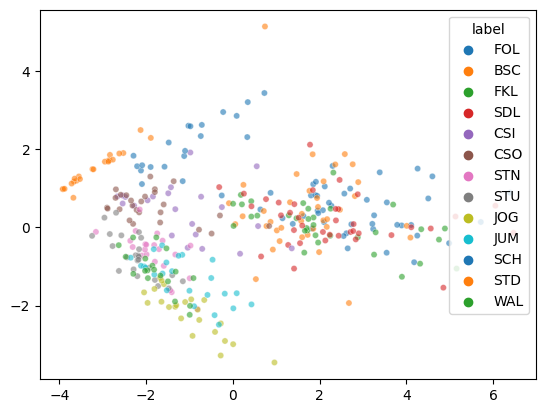

In [335]:
palette = sns.color_palette("tab10", df_test['label'].nunique())

sns.scatterplot(x=df_test_reducted[:,0],
                y=df_test_reducted[:,1],
                hue=df_test['label'],
                palette=palette,
                alpha=0.6, s=20)
plt.show()